In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import basedir, evaluations_dir
from embedding_utils import perform_pca_on_embeddings
from annotation_utils import load_marcotte_subtypes
from training_configuration import PATHWAYS_3C

model = "EGFR_MAPK__logobs"
data = "dream_cytof"

from common import evaluations_dir

embedding_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "embeddings_figure3c.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3C
    ]
)

# Only keep central values
embedding_df = embedding_df[
    (embedding_df.depth == 0) & (embedding_df.n_hidden == 8)
]


subtypes_marcotte = load_marcotte_subtypes(embedding_df.cell_line.unique())

pca_embeddings_dict = {}
for model in PATHWAYS_3C:
    # print(model)
    pca_embeddings_dict[model], _ = perform_pca_on_embeddings(embedding_df[embedding_df.model == model], n_components=8)


for model in PATHWAYS_3C:
    pca_embeddings_dict[model]["subtype_intrinsic"] = subtypes_marcotte["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"] = pca_embeddings_dict[model]["subtype_intrinsic"]
    pca_embeddings_dict[model]["luminalbasal"].replace(["LuminalA", "LuminalB", "HER2"], "Luminal", inplace=True)
    pca_embeddings_dict[model]["luminalbasal"].replace(["CL"], "Basal", inplace=True)

Explained variance for cytof_init BT20: [0.38448512 0.17635863 0.13802847 0.10823589 0.06895943 0.04840469
 0.03870241 0.01726754]; Total: 0.9804
Explained variance for cytof_init EVSAT: [0.32435144 0.20979809 0.14961179 0.12344904 0.07050232 0.05318481
 0.03076021 0.01457938]; Total: 0.9762
Explained variance for cytof_init HCC1500: [0.31937464 0.21499647 0.13045293 0.10415223 0.08290784 0.06450275
 0.04706261 0.0250327 ]; Total: 0.9885
Explained variance for cytof_init HCC2185: [0.37291253 0.18518735 0.14547525 0.09609679 0.0707102  0.06165935
 0.03222957 0.01768843]; Total: 0.9820
Explained variance for cytof_init MCF7: [0.34451403 0.23816536 0.16068684 0.08137308 0.06910574 0.04429069
 0.0322148  0.01897487]; Total: 0.9893
Explained variance for cytof_init UACC3199: [0.30799095 0.19594613 0.16067374 0.11047218 0.07701363 0.06184999
 0.03545911 0.02219603]; Total: 0.9716
Explained variance for cytof_init UACC893: [0.42436172 0.15737142 0.12168166 0.10681547 0.06665148 0.05153761
 0.

In [2]:
embedding_df

,cell_line,L1,context,samples,dataset,job,n_hidden,depth,dropout_rate,l1reg_inflater_output,...,L22,L23,L24,L25,L26,L27,L28,L29,L30,model
14820,c184A1,-0.046923,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14821,c184B5,-0.263869,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14822,cAU565,-0.018232,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14823,cBT474,0.241893,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
14824,cBT483,0.358532,cytof_init,BT20,train,0,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129915,cUACC3199,0.695101,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129916,cUACC812,0.536255,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129917,cUACC893,-0.014209,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg
129918,cZR751,0.475155,multimodal,all,train,9,8,0,0.1,0.01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EGFR_MAPK__logobs_tegfr_aggavg


In [3]:
pca_embedding_df = pd.concat(
    [
        pca_embeddings_dict[model].assign(model=model)
        for model in PATHWAYS_3C
    ]
)

# Embeddings annotated by Luminal/Basal

## First 2 PCA components only

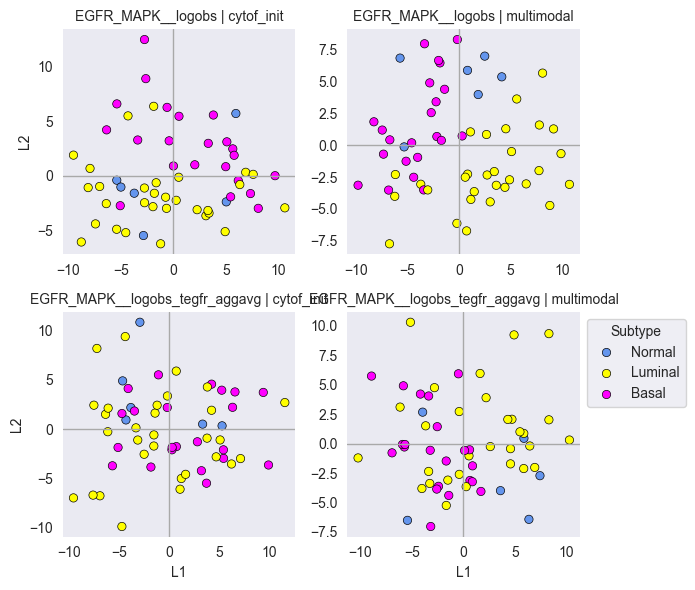

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="luminalbasal",
    palette={
        "Luminal": "yellow",
        "Basal": "magenta",
        "Normal": "cornflowerblue"
    },
    edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Titles without prefixes
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off

# Legend
plt.legend(title="Subtype", bbox_to_anchor=(1, 1))

# plt.savefig("fig1a_embeddings_allcontexts_onlyBT20split_LB_fixedge.svg")
plt.show()

## Check Luminal/Basal distributions across all PCA-ed latent components

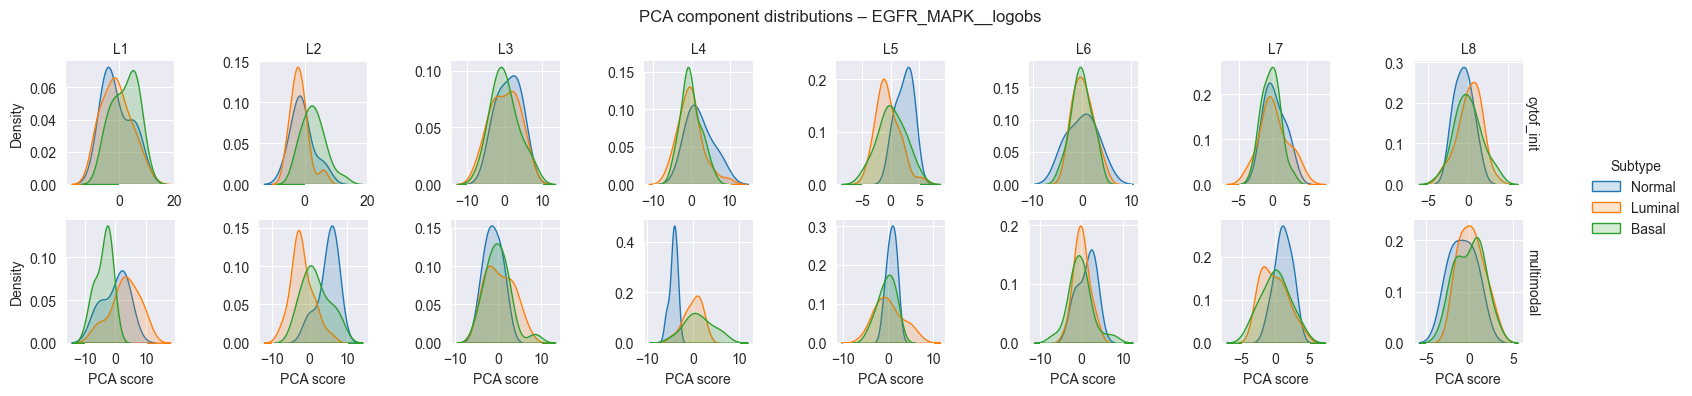

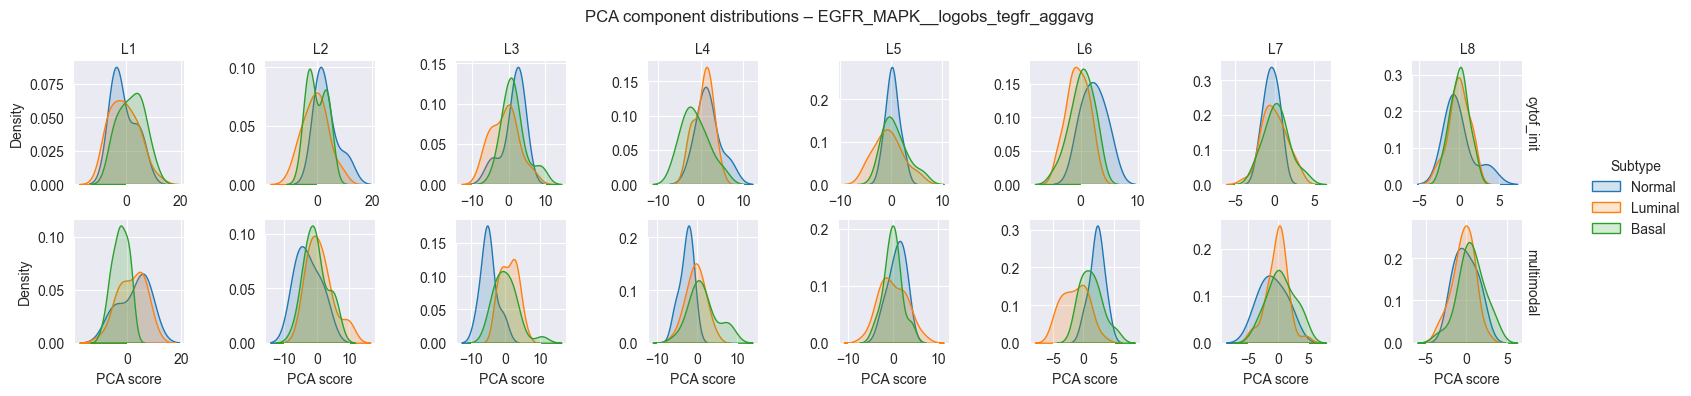

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "luminalbasal"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="luminalbasal",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="Subtype")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

# Check association with EGFR transcript levels

In [6]:
from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import load_data
from util import load_petab_base_files

samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs", data="dream_cytof"))
del petab_base_files["condition_table"]

cytof_init, _, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)
pp38 = cytof_init["p.p38"]
pp38 -= pp38.mean()
pp90rsk = cytof_init["p.p90RSK"]
pp90rsk -= pp90rsk.mean()
pmek = cytof_init["p.MEK"]
pmek -= pmek.mean()
del cytof_init

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
tegfr = transcriptomics["EGFR"]
tegfr -= tegfr.mean()
terbb2 = transcriptomics["ERBB2"]
terbb2 -= terbb2.mean()
tpls3 = transcriptomics["PLS3"]
tpls3 -= tpls3.mean()
del transcriptomics

proteomics, _, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)
pegfr = proteomics["EGFR"]
pegfr -= pegfr.mean()
perbb2 = proteomics["ERBB2"]
perbb2 -= proteomics.mean()
pisoc1 = proteomics["ISOC1"]
pisoc1 -= pisoc1.mean()
del proteomics

In [7]:
pca_embedding_df["p.p38"] = pp38.loc[pca_embedding_df.index]
pca_embedding_df["p.p90RSK"] = pp90rsk.loc[pca_embedding_df.index]
pca_embedding_df["p.MEK"] = pmek.loc[pca_embedding_df.index]
pca_embedding_df["tEGFR"] = tegfr.loc[pca_embedding_df.index]
pca_embedding_df["pEGFR"] = pegfr.loc[pca_embedding_df.index]
pca_embedding_df["pISOC1"] = pisoc1.loc[pca_embedding_df.index]
pca_embedding_df["tPLS3"] = tpls3.loc[pca_embedding_df.index]

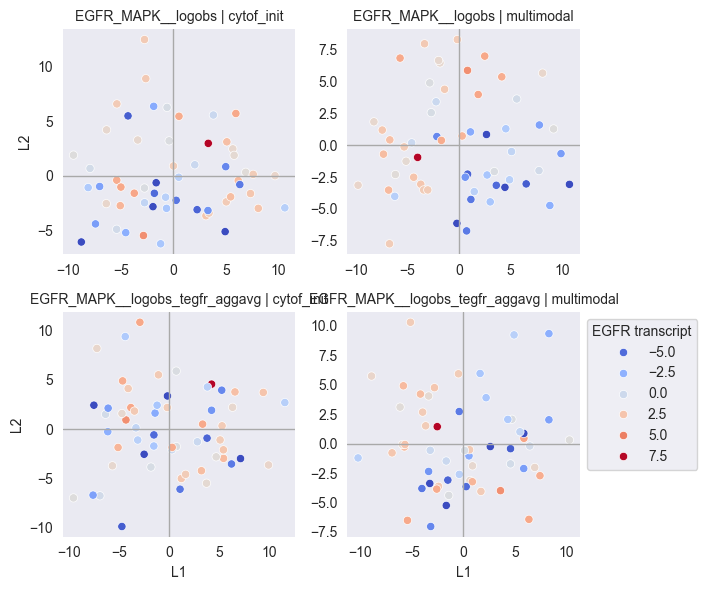

In [8]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="tEGFR",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="EGFR transcript", bbox_to_anchor=(1, 1))
# plt.savefig("fig1a_embeddings_allcontexts_onlyBT20split_tEGFR_fix.svg")

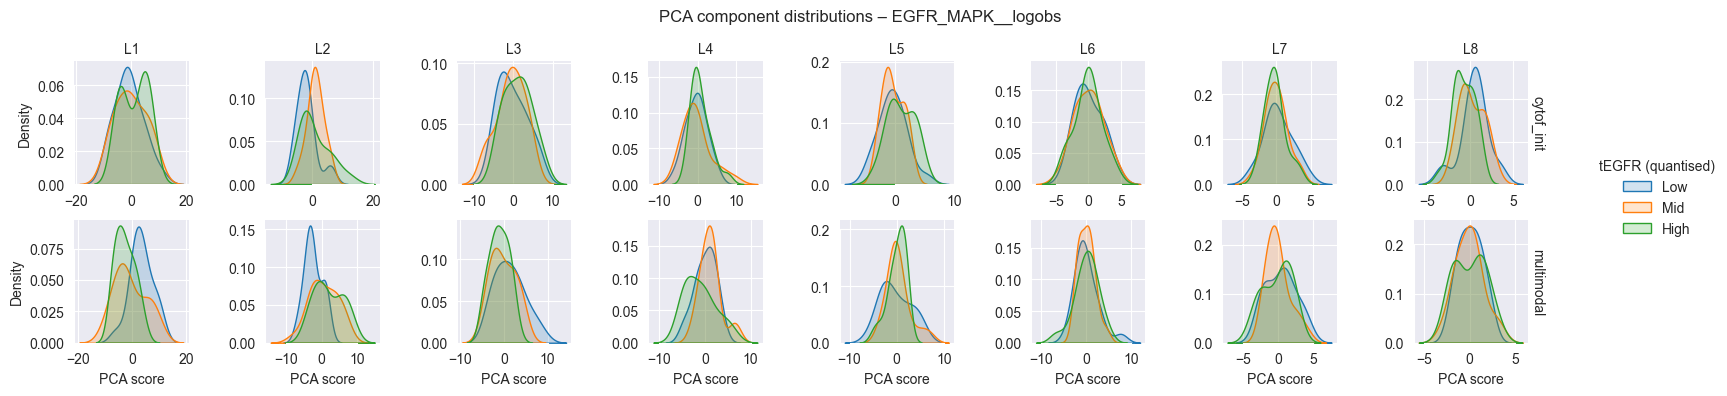

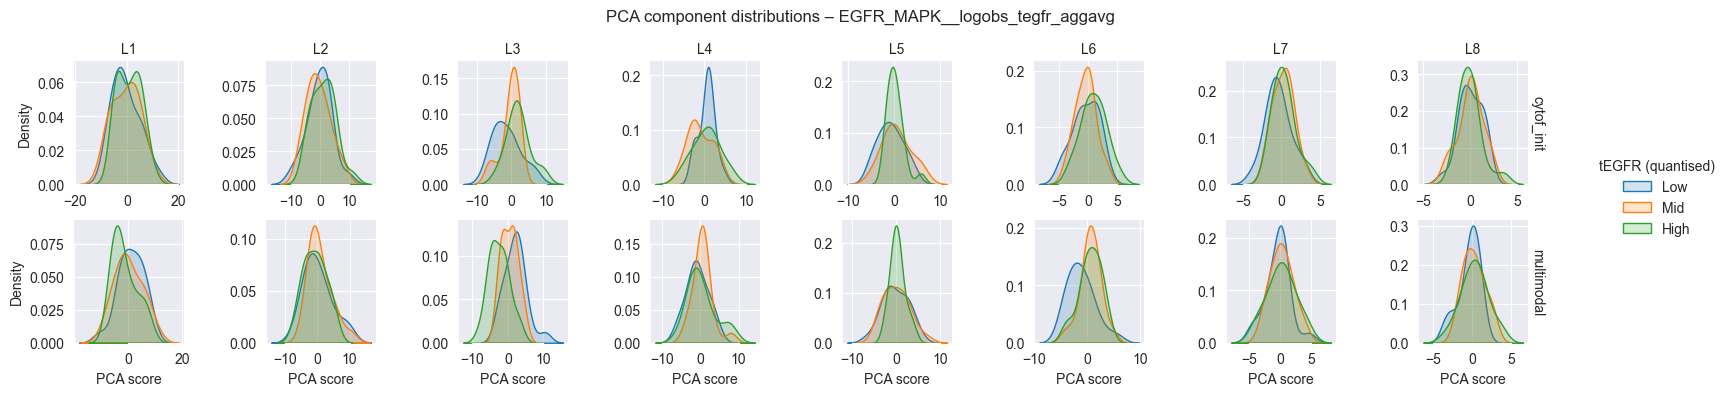

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Quantise tEGFR into quartiles (Q1–Q4)
    df_model["tEGFR_q"] = pd.qcut(
        df_model["tEGFR"],
        q=3,
        labels=["Low", "Mid", "High"]
    )

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "tEGFR_q"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="tEGFR_q",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="tEGFR (quantised)")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

## Check protein EGFR levels

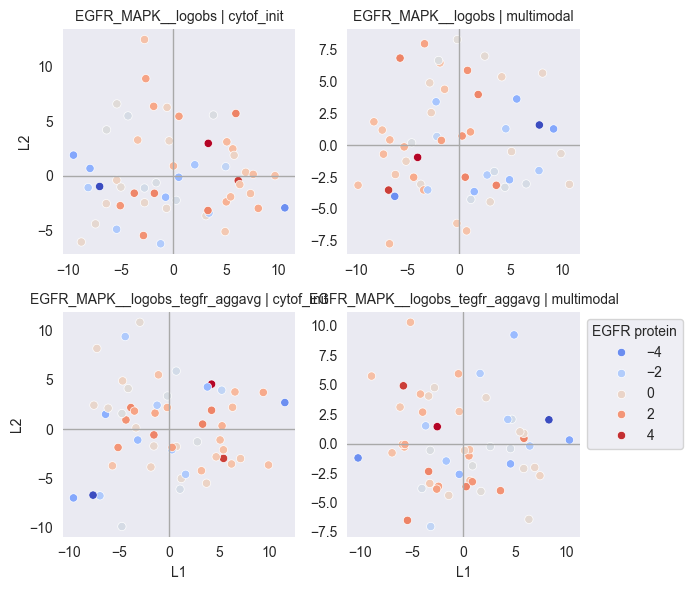

In [10]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="pEGFR",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="EGFR protein", bbox_to_anchor=(1, 1))
# plt.savefig("fig1a_embeddings_allcontexts_onlyBT20split_tEGFR_fix.svg")

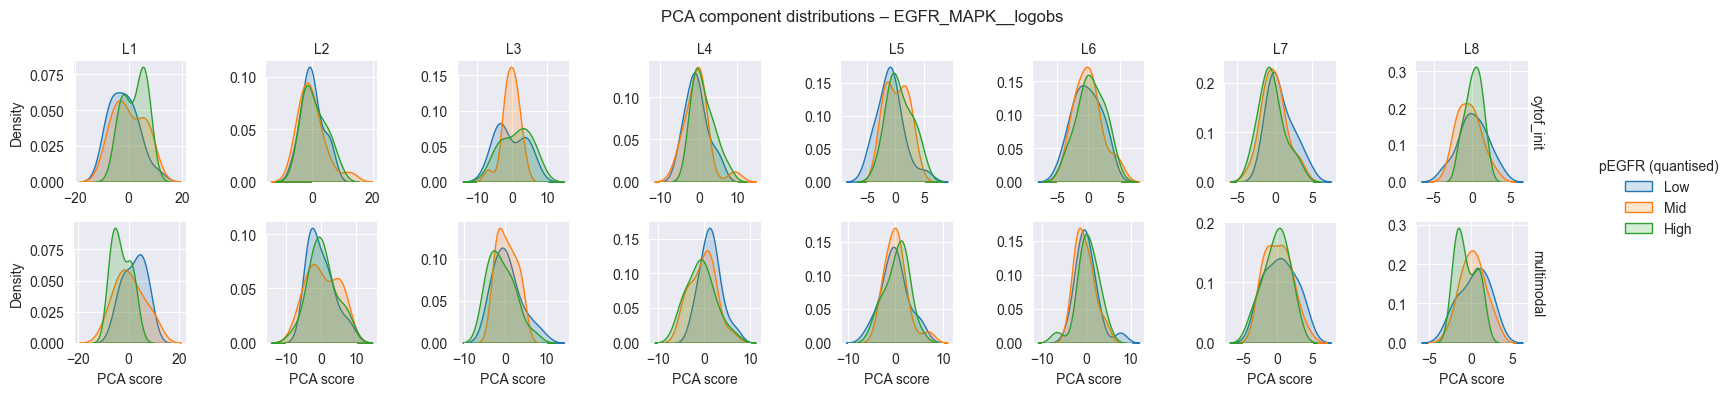

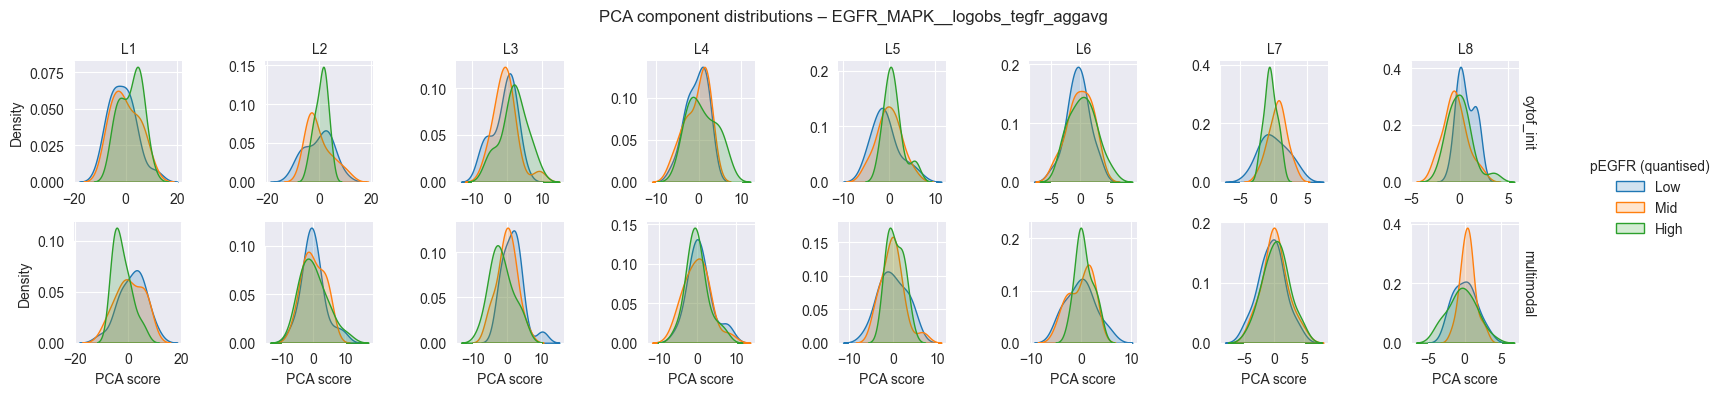

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Quantise tEGFR into quartiles (Q1–Q4)
    df_model["pEGFR_q"] = pd.qcut(
        df_model["pEGFR"],
        q=3,
        labels=["Low", "Mid", "High"]
    )

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "pEGFR_q"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="pEGFR_q",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="pEGFR (quantised)")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

# Check phospho-p90RSK at time 0

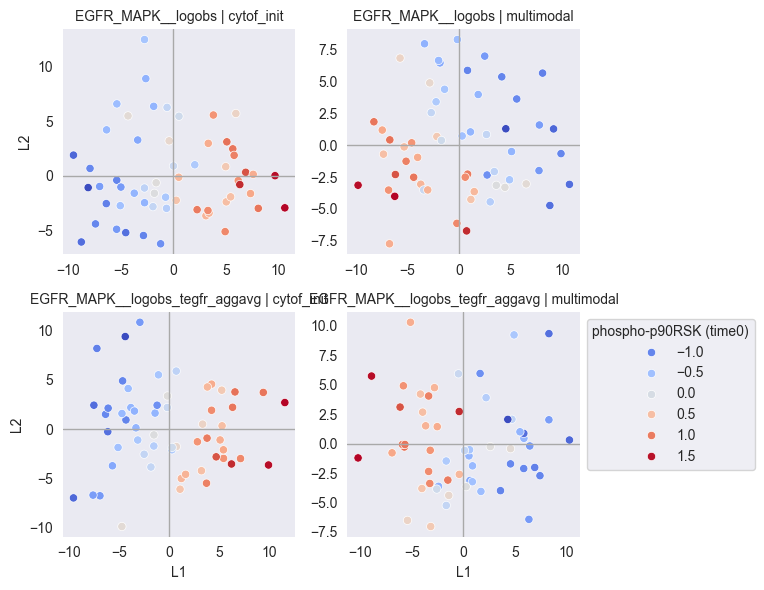

In [12]:
g = sns.FacetGrid(
    pca_embedding_df[
        (pca_embedding_df.samples.isin(["all"]))
    ],
    row="model",
    row_order=["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
    col="context",
    col_order=["cytof_init", "multimodal"],
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.scatterplot,
    x="L1",
    y="L2",
    hue="p.p90RSK",
    palette="coolwarm",
    # edgecolor="black",
)

# Axis labels
g.set_axis_labels("L1", "L2")

# Remove the "context = " prefix from column titles
g.set_titles(row_template="{row_name}", col_template="{col_name}")

# Remove default seaborn grid/spines
sns.despine(left=True, bottom=True)

# Draw clean axes at (0,0)
for ax in g.axes.flat:
    ax.axhline(0, color="darkgray", linewidth=1)
    ax.axvline(0, color="darkgray", linewidth=1)
    ax.grid(False)  # ensure grid is off


plt.legend(title="phospho-p90RSK (time0)", bbox_to_anchor=(1, 1))

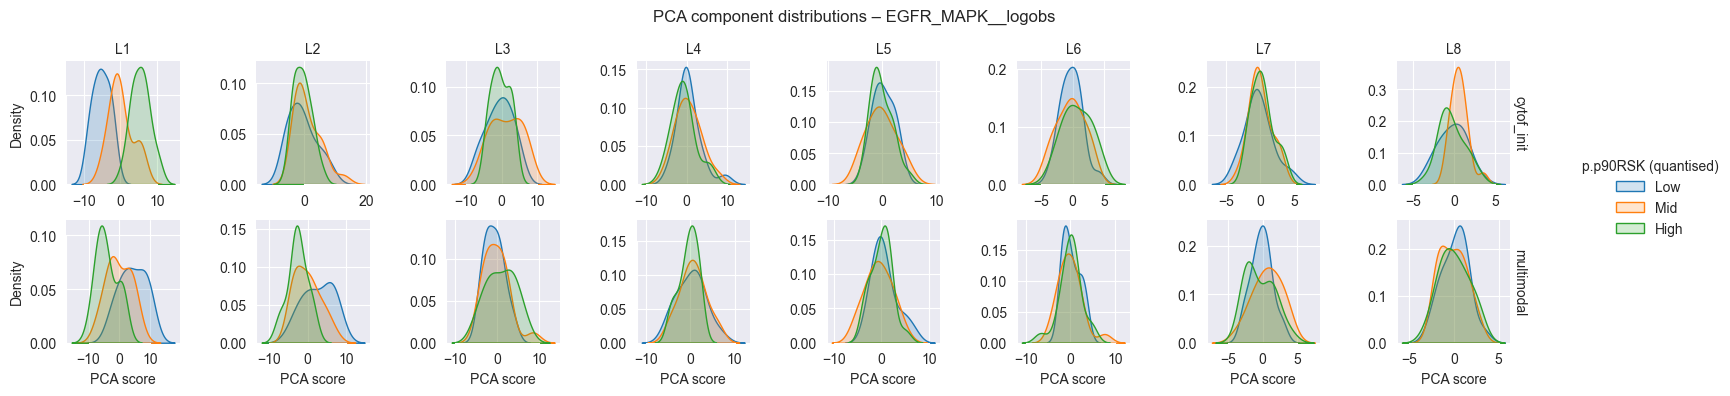

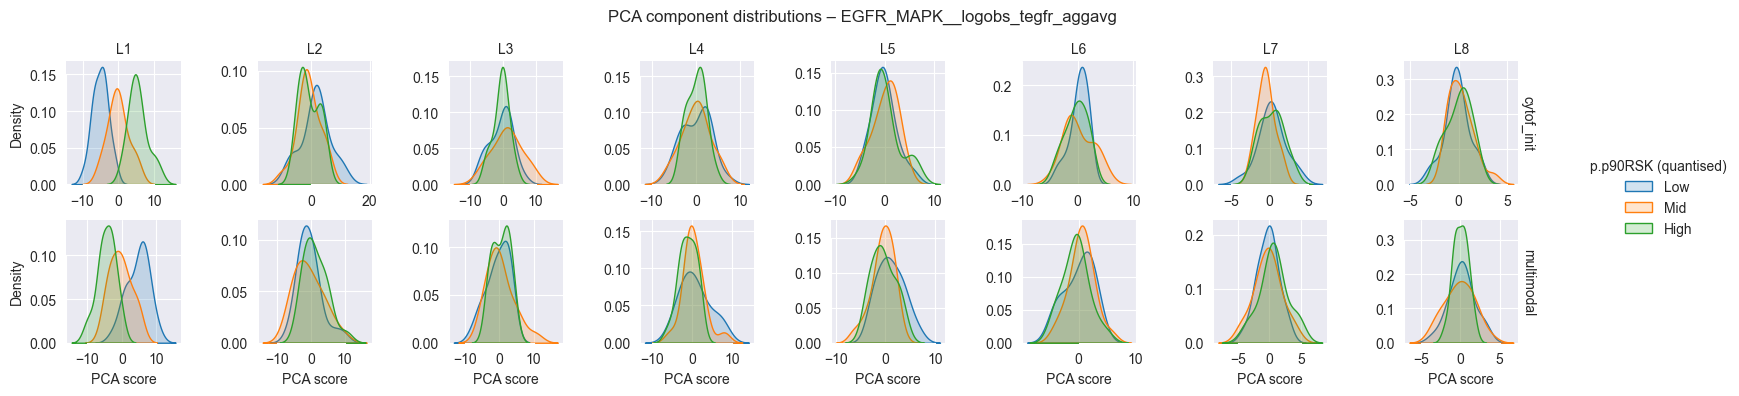

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Which PCA components to include
pca_components = [f"L{i}" for i in range(1, 9)]

model_order = ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]
context_order = ["cytof_init", "multimodal"]

for model in model_order:
    # Subset just this model and your "all" samples
    df_model = pca_embedding_df[
        (pca_embedding_df["samples"].isin(["all"]))
        & (pca_embedding_df["model"] == model)
        & (pca_embedding_df["context"].isin(context_order))
    ].copy()

    # Quantise tEGFR into quartiles (Q1–Q4)
    df_model["p.p90RSK_q"] = pd.qcut(
        df_model["p.p90RSK"],
        q=3,
        labels=["Low", "Mid", "High"]
    )

    # Long format: one column for component, one for its value
    df_long = df_model.melt(
        id_vars=["context", "p.p90RSK_q"],
        value_vars=pca_components,
        var_name="component",
        value_name="score",
    )

    g = sns.FacetGrid(
        df_long,
        row="context",
        row_order=context_order,
        col="component",
        col_order=pca_components,
        sharex=False,
        sharey=False,
        hue="p.p90RSK_q",            # remove if you want overall distribution only
        margin_titles=True,
        height=2.0,
        aspect=1.0,
    )

    # Histogram-like diagonal plots (pairplot-style)
    g.map_dataframe(
        sns.kdeplot,
        x="score",
        common_norm=False,
        fill=True,
        alpha=0.2,
        linewidth=1,
    )

    # Axis labels
    g.set_axis_labels("PCA score", "Density")

    # Clean titles
    g.set_titles(row_template="{row_name}", col_template="{col_name}")

    # Legend
    g.add_legend(title="p.p90RSK (quantised)")

    # Despine and tidy layout
    sns.despine(trim=True)
    plt.subplots_adjust(top=0.85)
    plt.suptitle(f"PCA component distributions – {model}", y=0.98)

    plt.show()
    # Optionally:
    # plt.savefig(f"fig_pca_hist_{model}.svg", bbox_inches="tight")

Comparison: lots of p.p90RSK structure

In [14]:
import numpy as np
from sklearn.linear_model import LinearRegression

for model in ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"]:
    print("-----------------------------")
    for context in ["cytof_init", "multimodal"]:
        sub_df = pca_embedding_df[(pca_embedding_df.model == model) & (pca_embedding_df.context == context)]
        for samples in ["all"]:
            X = sub_df[(sub_df.samples == samples)][[f"L{i}" for i in range(1, 9)]].values
            y = sub_df[(sub_df.samples == samples)]["p.p90RSK"].values

            reg = LinearRegression().fit(X, y)
            direction = reg.coef_ / np.linalg.norm(reg.coef_)

            proj = X @ direction
            corr = np.corrcoef(proj, y)[0,1]
            print(f"Best linear projection correlation of embeddings with time0 p.p90RSK for {model}, {context}, {samples}:", corr)

-----------------------------
Best linear projection correlation of embeddings with time0 p.p90RSK for EGFR_MAPK__logobs, cytof_init, all: 0.969631993883726
Best linear projection correlation of embeddings with time0 p.p90RSK for EGFR_MAPK__logobs, multimodal, all: 0.9479825245871141
-----------------------------
Best linear projection correlation of embeddings with time0 p.p90RSK for EGFR_MAPK__logobs_tegfr_aggavg, cytof_init, all: 0.9717523727044093
Best linear projection correlation of embeddings with time0 p.p90RSK for EGFR_MAPK__logobs_tegfr_aggavg, multimodal, all: 0.9606623781608891


# Compute most aligned marker in each context/features/split

In [15]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA

def top_markers_for_embedding(
    embedding_df: pd.DataFrame,
    tegfr: pd.Series,
    model: str,
    context: str,
    n_hidden: int,
    samples: str,
    features_df: pd.DataFrame,
    n_top: int = 1,
    use_tEGFR_axis: bool = False,
):
    """
    Find markers aligned with main and orthogonal directions of embedding.

    Parameters
    ----------
    embedding_df : DataFrame with ['L1','L2','context','samples',index=cell_line]
    tegfr        : Series indexed by cell_line
    context      : which context to filter
    samples      : which CV split
    features_df  : DataFrame with index = cell_line and marker columns
    n_top        : number of top markers to return
    use_tEGFR_axis : if True, define the primary axis by correlation with tEGFR,
                     otherwise use PC1 of embedding
    """
    sub_embed = embedding_df[
        (embedding_df["model"] == model) &
        (embedding_df["context"] == context) &
        (embedding_df["samples"] == samples)
    ][[f"L{i}" for i in range(1, n_hidden+1)]]

    common_idx = sub_embed.index.intersection(features_df.index).intersection(tegfr.index)
    if len(common_idx) < 3:
        return None

    X_embed = sub_embed.loc[common_idx].values
    feats = features_df.loc[common_idx].select_dtypes(include=[np.number])
    t = tegfr.loc[common_idx].values.reshape(-1,1)

    # --- define main / orthogonal axis ---
    if use_tEGFR_axis:
        reg = LinearRegression().fit(X_embed, t)
        main_axis = reg.coef_.ravel()
        main_axis /= np.linalg.norm(main_axis)
        orth_axis = np.array([-main_axis[1], main_axis[0]])  # 90° rotation
    else:
        pca = PCA(n_components=2).fit(X_embed)
        main_axis = pca.components_[0]
        orth_axis = pca.components_[1]

    # project embedding onto axes
    main_scores = X_embed @ main_axis
    orth_scores = X_embed @ orth_axis

    # correlations
    def corr_with_scores(scores):
        return feats.apply(lambda c: np.corrcoef(c.values, scores)[0,1])

    corr_main = corr_with_scores(main_scores).dropna()
    corr_orth = corr_with_scores(orth_scores).dropna()

    top_main = corr_main.abs().sort_values(ascending=False).head(n_top)
    top_orth = corr_orth.abs().sort_values(ascending=False).head(n_top)

    return {
        "model": model,
        "context": context,
        "samples": samples,
        "top_main": list(top_main.index),
        "corr_main": list(corr_main.loc[top_main.index]),
        "top_orth": list(top_orth.index),
        "corr_orth": list(corr_orth.loc[top_orth.index]),
    }

In [16]:
import itertools as itt
import numpy as np
from common import FEATURES_OUTFILE
from training_configuration import CONTEXTS_FEATURES_3C, SPLITS

results = []
for model, (ctx, feats), split in itt.product(
        ["EGFR_MAPK__logobs", "EGFR_MAPK__logobs_tegfr_aggavg"],
        zip(["cytof_init", "multimodal"], ["RFE_15_permute", "RFE_10_permute"]),
        ["all"]
):
    # load features_df as you do already
    features_df = pd.concat([
        pd.read_csv
        (FEATURES_OUTFILE.format(
            model=model, data=data,
            context=ctx, features=feats,
            dataset=ds, samples=split)
        )
        for ds in ["train","val"]
    ]).set_index("preequilibrationConditionId")

    res = top_markers_for_embedding(
        embedding_df=pca_embedding_df,
        tegfr=tegfr,
        model=model,
        context=ctx,
        samples=split,
        n_hidden=8,
        features_df=features_df,
        n_top=3,
        use_tEGFR_axis=False  # flip False/True depending on analysis
    )
    if res:
        results.append(res)

pd.DataFrame(results)

,model,context,samples,top_main,corr_main,top_orth,corr_orth
0,EGFR_MAPK__logobs,cytof_init,all,"[p.p90RSK, p.ERK, p.MKK4]","[0.914547050459305, 0.7857025062964018, 0.7821...","[p.MEK, p.STAT3, IdU]","[-0.6400217120125226, 0.5881179765870271, 0.47..."
1,EGFR_MAPK__logobs,multimodal,all,"[p.p90RSK, p.p38, p.ERK]","[-0.7348408051140984, -0.728720423826026, -0.6...","[pITGA3, p.MEK, tZG16B]","[0.6200252002370673, -0.581965625303073, -0.58..."
2,EGFR_MAPK__logobs_tegfr_aggavg,cytof_init,all,"[p.p90RSK, p.MKK4, p.ERK]","[0.9264418775901271, 0.809169093422507, 0.7746...","[IdU, p.RB, p.STAT3]","[-0.5290894424618167, -0.4493264978667003, 0.4..."
3,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,all,"[p.p90RSK, p.ERK, p.MKK4]","[-0.8511324109724203, -0.738439241541361, -0.7...","[tGDF15, tGJA5, p.HER2]","[-0.7105437114423239, 0.36853431849588086, 0.3..."


## Parameters on embeddings

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import itertools as itt
from sklearn.decomposition import PCA
from common import evaluations_dir
from training_configuration import PATHWAYS_3C

data = "dream_cytof"

par_dev_df = pd.concat(
    [
        pd.read_csv(evaluations_dir / model / data/ "param_devs_figure3c.csv", index_col=0).assign(model=model)
        for model in PATHWAYS_3C
    ]
)
par_dev_df = par_dev_df[(par_dev_df.depth == 0) & (par_dev_df.n_hidden == 8) & (par_dev_df.samples == "all")]

not_param_cols = [
    "cell_line", "model", "context", "features",
    "samples", "dataset",
    "n_hidden", "depth", "dropout_rate",
    "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss", "inflater_output_reg_epoch", "inflater_bound",
    "n_epoch", "multiheaded",
    "job"
]
param_cols = [col for col in par_dev_df.columns if col not in not_param_cols]

mean_par_dev_df = par_dev_df.groupby(["model", "context", "cell_line", "samples"])[param_cols].mean().reset_index()

In [22]:
len(param_cols)

44

In [23]:
def plot_parameters_on_embeddings(
        pca_embedding_df: pd.DataFrame,
        param_dev_df: pd.DataFrame,
        context: str,
        param_cols: list[str],
):
    # Mean parameter deviations
    mean_par_dev_df = (
        param_dev_df
        .groupby(["context", "features", "cell_line", "samples"])[param_cols]
        .mean()
        .reset_index()
    )
    context_par_dev_df = mean_par_dev_df[mean_par_dev_df.context == context]

    # Merge with PCA embeddings
    param_plot_df = (
        pca_embedding_df[pca_embedding_df.context == context]
        .reset_index()
        .merge(
            context_par_dev_df,
            on=["cell_line", "context", "samples"],
            how="left"
        )
    )

    # ---- Convert to long format (one col per parameter) ----
    df_long = param_plot_df.melt(
        id_vars=["L1", "L2", "samples"],
        value_vars=param_cols,
        var_name="param",
        value_name="value"
    )

    # Remove params with no variation
    df_long = df_long.groupby("param").filter(lambda d: d["value"].var() > 0)

    # ---- FacetGrid: 1 row, columns = parameters ----
    g = sns.FacetGrid(
        df_long,
        col="param",
        col_wrap=6,
        sharex=True,
        sharey=True,
        height=3,
        aspect=1.2,
    )

    g.map_dataframe(
        sns.scatterplot,
        x="L1",
        y="L2",
        hue="value",
        palette="coolwarm",
        edgecolor="none",
        s=20,
    )

    for ax in g.axes.flat:
        ax.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

    g.set_axis_labels("L1", "L2")
    g.set_titles(col_template="{col_name}")

    sns.despine(trim=True)
    plt.tight_layout()
    plt.show()

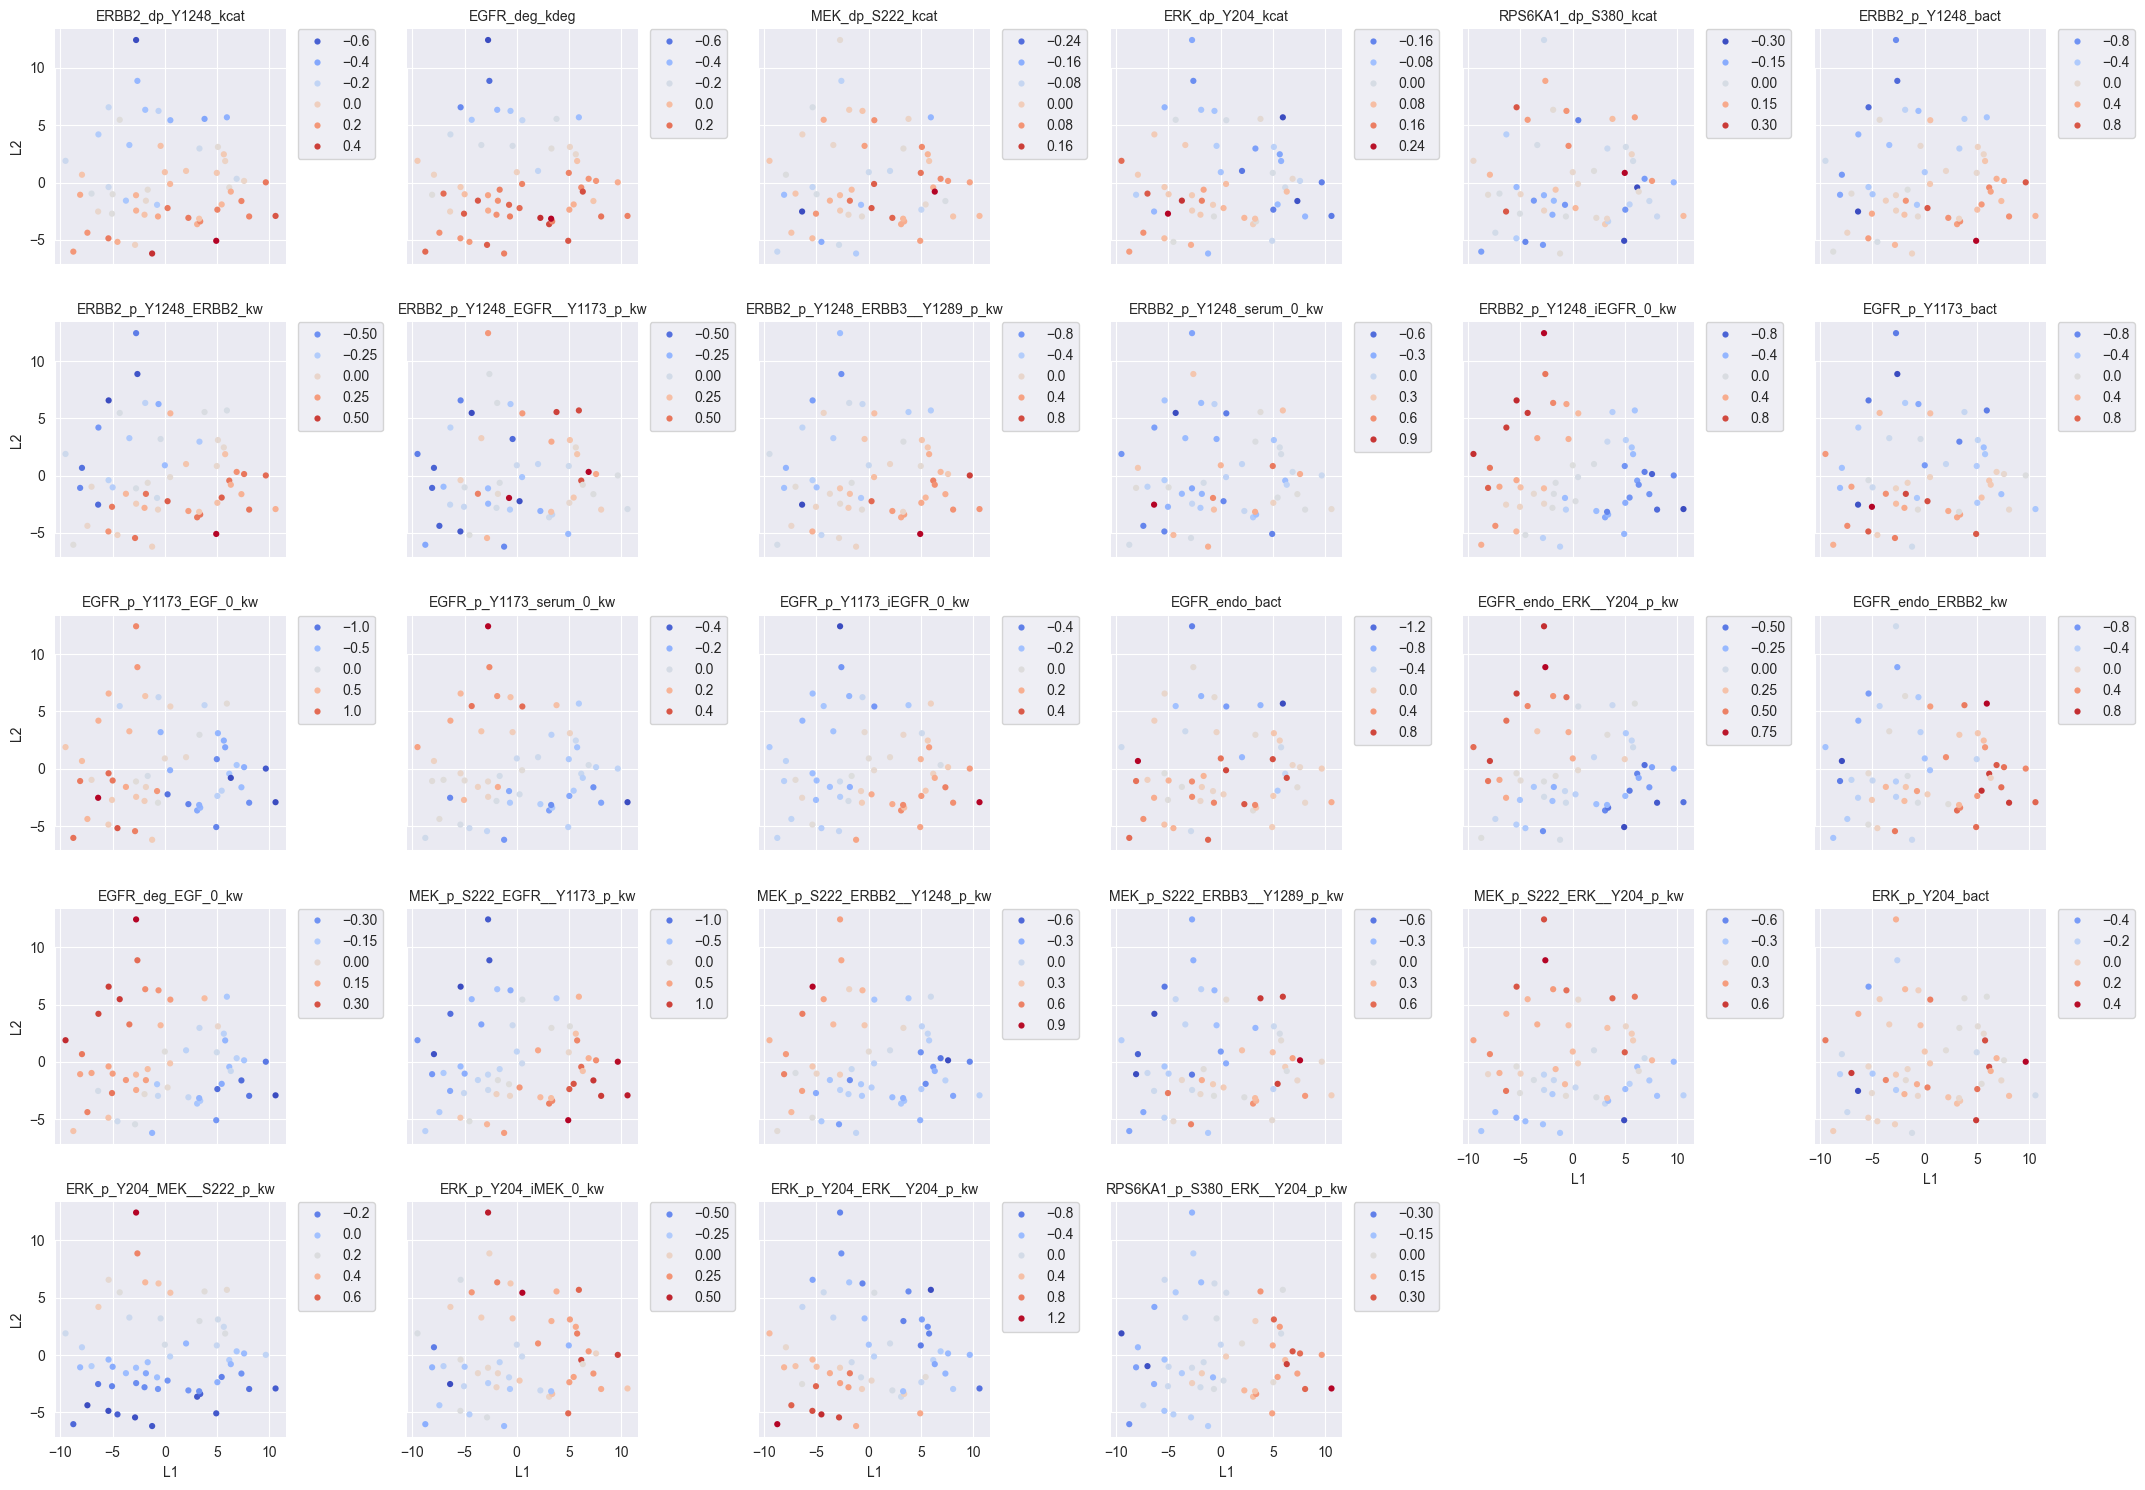

In [25]:
# params_interest = [
#     'RPS6KA1_p_S380_ERK__Y204_p_kw',
#     'ERK_p_Y204_MEK__S222_p_kw',
#     'TOPK_p_Y74_EGFR__Y1173_p_kw',
#     'ERBB2_p_Y1248_ERBB2_kw',
#     'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
#     'ERBB2_p_Y1248_serum_0_kw'
# ]

# params_interest = [
#     'ERK_p_Y204_iMEK_0_kw',
#     'ERBB2_p_Y1248_iEGFR_0_kw',
#     'MEK_p_S222_ERK__Y204_p_kw',
#     'EGFR_p_Y1173_iEGFR_0_kw',
#     'EGFR_p_Y1173_EGF_0_kw',
# ]

plot_parameters_on_embeddings(
    pca_embedding_df[pca_embedding_df.model == "EGFR_MAPK__logobs"],
    par_dev_df[par_dev_df.model == "EGFR_MAPK__logobs"],
    "cytof_init",
    param_cols
)

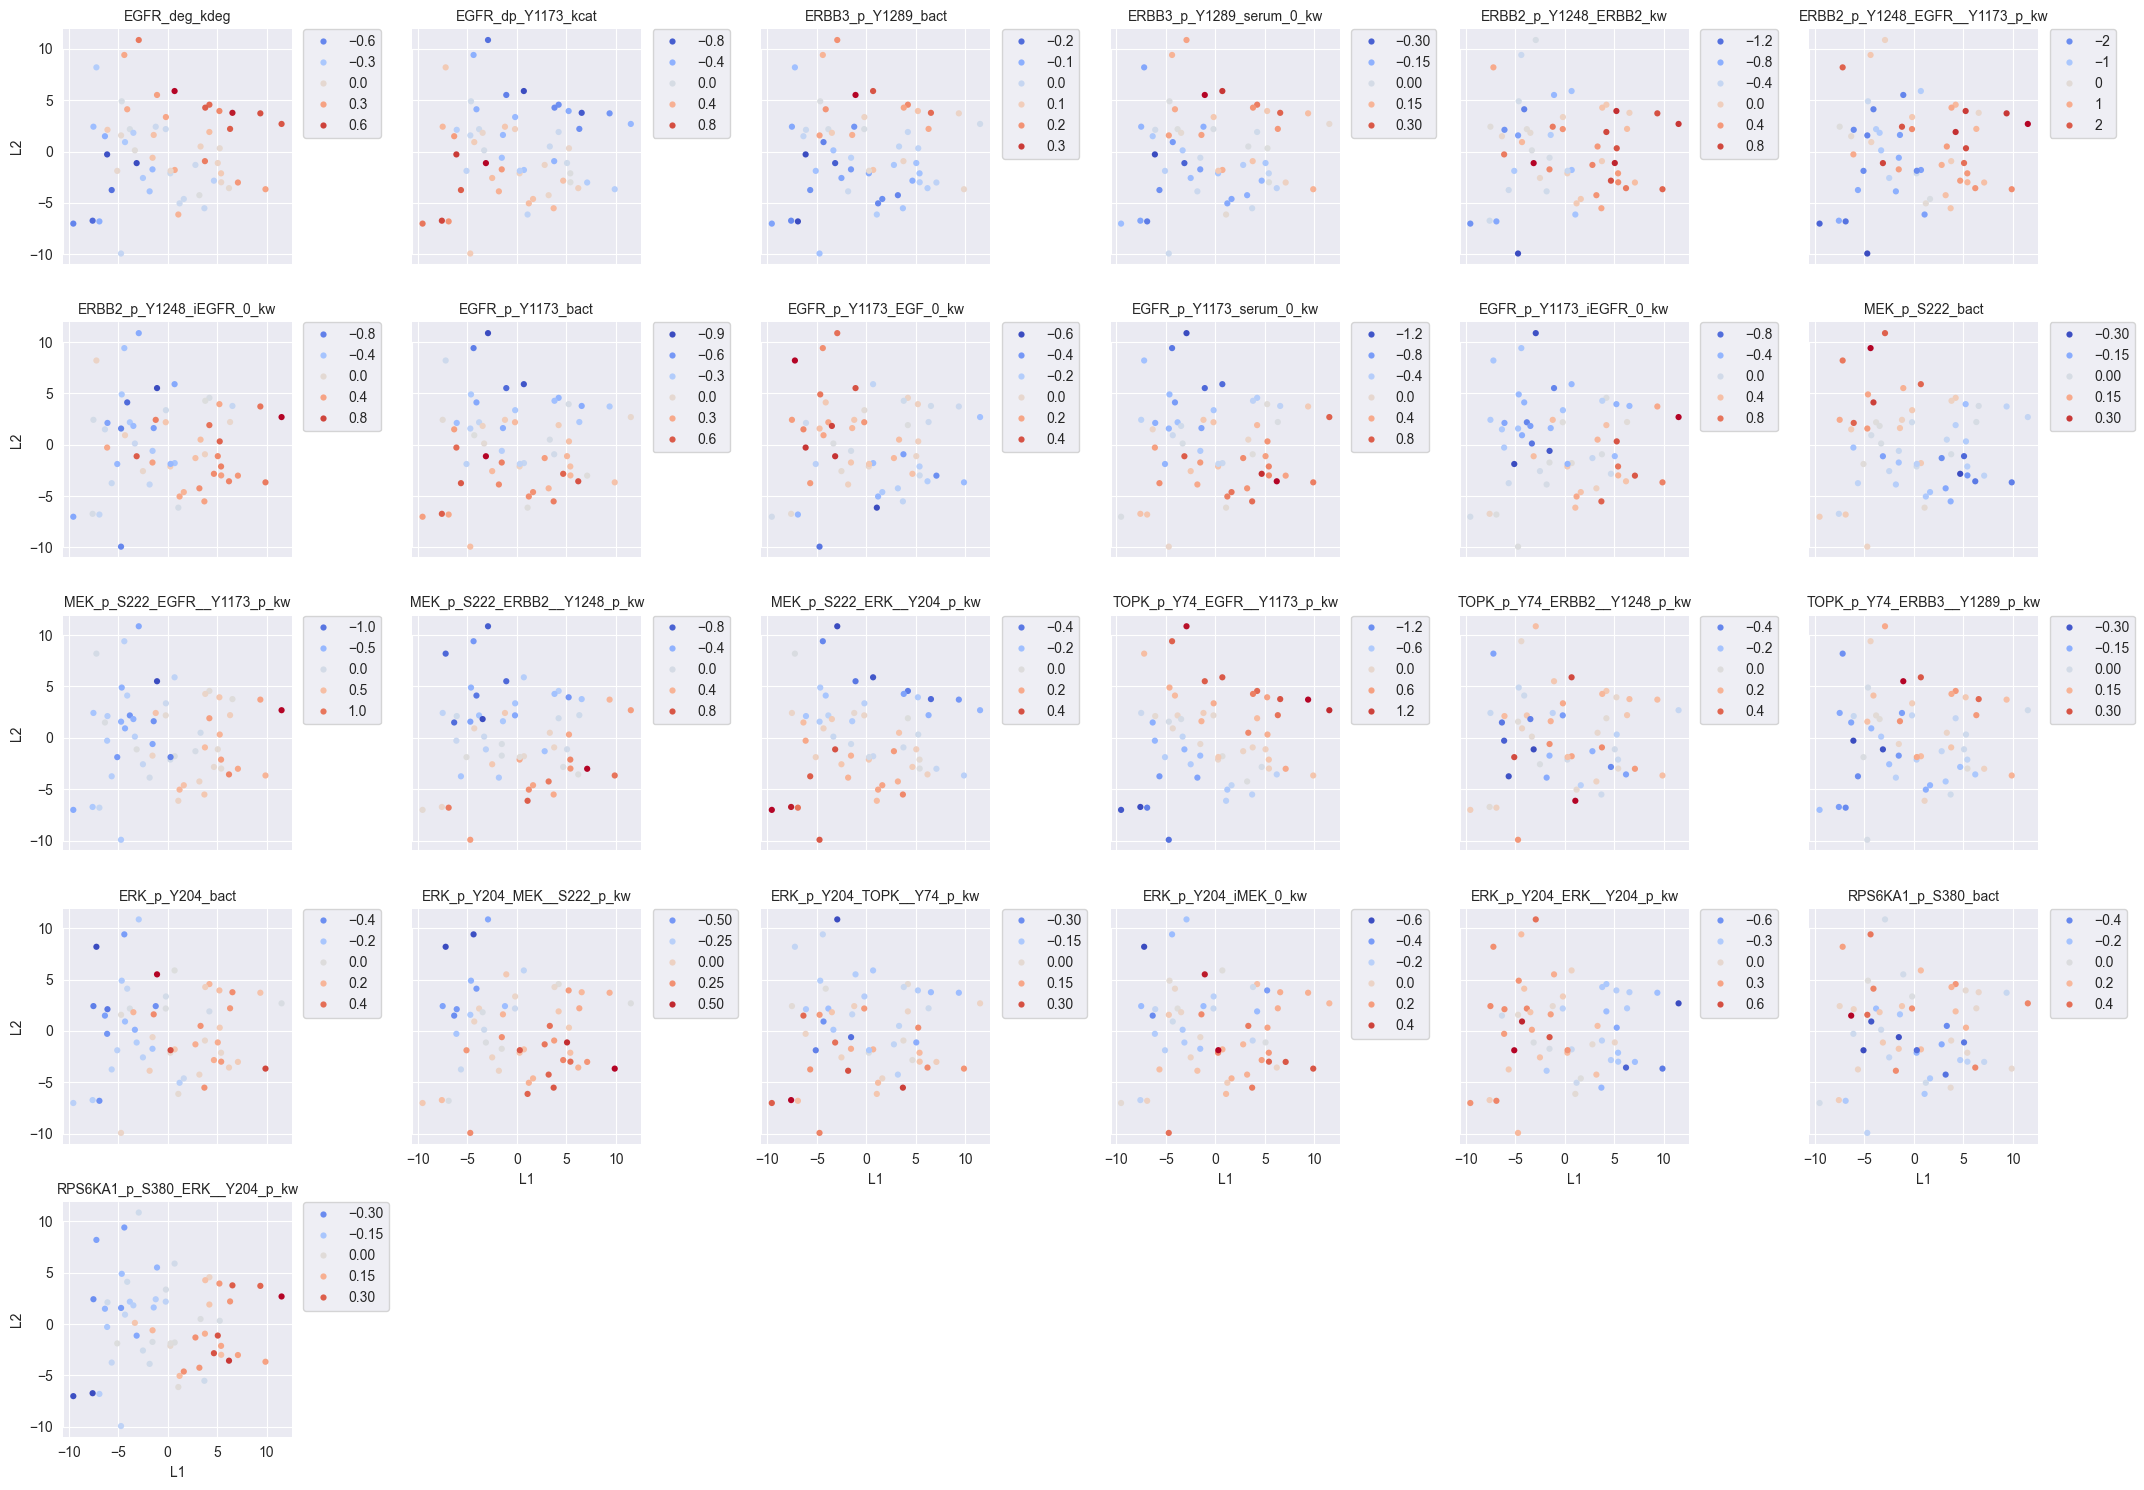

In [26]:
# params_interest = [
#     'RPS6KA1_p_S380_ERK__Y204_p_kw',
#     'ERK_p_Y204_MEK__S222_p_kw',
#     'TOPK_p_Y74_EGFR__Y1173_p_kw',
#     'ERBB2_p_Y1248_ERBB2_kw',
#     'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
#     'ERBB2_p_Y1248_serum_0_kw'
# ]

# params_interest = [
#     'ERK_p_Y204_iMEK_0_kw',
#     'ERBB2_p_Y1248_iEGFR_0_kw',
#     'MEK_p_S222_ERK__Y204_p_kw',
#     'EGFR_p_Y1173_iEGFR_0_kw',
#     'EGFR_p_Y1173_EGF_0_kw',
# ]

plot_parameters_on_embeddings(
    pca_embedding_df[pca_embedding_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    par_dev_df[par_dev_df.model == "EGFR_MAPK__logobs_tegfr_aggavg"],
    "cytof_init",
    param_cols
)

# Run correlation with entire feature set across modalities

In [27]:
samples = get_samples("dream_cytof")
petab_base_files = load_petab_base_files(Conf(model="EGFR_MAPK__logobs", data="dream_cytof"))
del petab_base_files["condition_table"]

cytof_init, _, _, _ = load_data(
    contextualization="cytof_init",
    samples=samples,
    features=None,
    **petab_base_files,
)

transcriptomics, _, _, _ = load_data(
    contextualization="transcriptomics",
    samples=samples,
    features=None,
    **petab_base_files,
)

proteomics, _, _, _ = load_data(
    contextualization="proteomics",
    samples=samples,
    features=None,
    **petab_base_files,
)

In [28]:
cytof_prefixed = cytof_init.add_prefix("ph.")
transcriptomics_prefixed = transcriptomics.add_prefix("tx.")
proteomics_prefixed = proteomics.add_prefix("px.")

all_features = pd.concat(
    [cytof_prefixed, transcriptomics_prefixed, proteomics_prefixed],
    axis=1
)


all_features.shape

(58, 22760)

In [29]:
from tqdm import tqdm
import numpy as np
import itertools as itt
import pandas as pd

res = []
for model, context, parameter in itt.product(
    [
        "EGFR_MAPK__logobs",
        "EGFR_MAPK__logobs_tegfr_aggavg"
    ],
    [
        "cytof_init",
        "multimodal"
    ],
    param_cols
):

    # Select parameter values
    param_series = mean_par_dev_df[
        (mean_par_dev_df.model == model) & (mean_par_dev_df.context == context)
    ][["cell_line", parameter]].sort_values("cell_line")[parameter].values

    # Skip parameters with no valid values
    valid_param = param_series[~np.isnan(param_series)]
    if valid_param.size == 0:
        continue

    # Skip parameters with zero variance (would still give NaN correlation)
    if np.nanstd(valid_param) == 0:
        continue


    n_total = len(param_series)

    for marker in tqdm(all_features.columns, desc=f"{model}, {context}, {parameter}"):

        marker_series = all_features[marker].sort_index().values

        # Pairwise non-NaN mask
        mask = ~np.isnan(param_series) & ~np.isnan(marker_series)
        n_valid = mask.sum()

        # Require at least 50% valid (pairwise)
        if n_valid == 0 or n_valid < 0.5 * n_total:
            continue

        x = param_series[mask]
        y = marker_series[mask]

        corr = np.corrcoef(x, y)[0, 1]

        res.append(
            {
                "model": model,
                "context": context,
                "parameter": parameter,
                "marker": marker,
                "correlation": corr,
                "n_valid": n_valid,
                "fraction_valid": n_valid / n_total,
            }
        )

correlations_params_all_markers = pd.DataFrame(res)

EGFR_MAPK__logobs, cytof_init, ERBB2_dp_Y1248_kcat: 100%|██████████| 22760/22760 [00:02<00:00, 8917.50it/s] 
EGFR_MAPK__logobs, cytof_init, ERK_dp_Y204_kcat: 100%|██████████| 22760/22760 [00:01<00:00, 12957.71it/s]
EGFR_MAPK__logobs, cytof_init, RPS6KA1_dp_S380_kcat: 100%|██████████| 22760/22760 [00:01<00:00, 13191.62it/s]
EGFR_MAPK__logobs, cytof_init, ERBB2_p_Y1248_bact: 100%|██████████| 22760/22760 [00:01<00:00, 12816.63it/s]
EGFR_MAPK__logobs, cytof_init, ERBB2_p_Y1248_ERBB2_kw: 100%|██████████| 22760/22760 [00:01<00:00, 12311.58it/s]
EGFR_MAPK__logobs, cytof_init, ERBB2_p_Y1248_EGFR__Y1173_p_kw: 100%|██████████| 22760/22760 [00:01<00:00, 12721.27it/s]
EGFR_MAPK__logobs, cytof_init, ERBB2_p_Y1248_ERBB3__Y1289_p_kw: 100%|██████████| 22760/22760 [00:01<00:00, 12755.73it/s]
EGFR_MAPK__logobs, cytof_init, ERBB2_p_Y1248_serum_0_kw: 100%|██████████| 22760/22760 [00:01<00:00, 13081.27it/s]
EGFR_MAPK__logobs, cytof_init, ERBB2_p_Y1248_iEGFR_0_kw: 100%|██████████| 22760/22760 [00:01<00:00, 

In [30]:
# Save CSV
correlations_params_all_markers.to_csv("correlations_parameters_allmarkers_base&tEGFR_cytof&multimodal_nhidden8.csv")

## Re-load from here, run stat-tests, adjust p-values and run enrichment analysis

In [246]:
correlations_params_all_markers = pd.read_csv("correlations_parameters_allmarkers_base&tEGFR_cytof&multimodal_nhidden8.csv")

In [32]:
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from scipy import stats
import gseapy as gp

# Select only biological genes (REMOVE prefixes AFTER selecting)
molecular_mask = (
    all_features.columns.str.startswith("tx.") |
    all_features.columns.str.startswith("px.") |
    all_features.columns.str.startswith("ph.")  # optional
)
molecular_features = all_features.loc[:, molecular_mask]

# Merge correlations with molecular features only
corr_df = correlations_params_all_markers[
    correlations_params_all_markers.marker.isin(molecular_features.columns)
].copy()

# --- Fisher Z transform p-values ---
def correlation_pval(r, n):
    """Two-sided p-value for correlation using Fisher Z."""
    # Avoid division error
    r = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    z_stat = z / se
    p = 2 * (1 - stats.norm.cdf(abs(z_stat)))
    return p


# Number of samples used for correlations
# Mean parameter deviations must align with all_features indices
n_samples = len(molecular_features)

corr_df["pval"] = corr_df["correlation"].apply(lambda r: correlation_pval(r, n_samples))

# -------------------------------
# MULTIPLE TESTING PER GROUP
# -------------------------------

corr_df["pval_adj"] = np.nan

for (model, context, parameter), group_idx in corr_df.groupby(
    ["model", "context", "parameter"]
).groups.items():

    idx = list(group_idx)
    pvals = corr_df.loc[idx, "pval"].values

    # mask for finite p-values only
    mask = np.isfinite(pvals)
    if mask.sum() == 0:
        # nothing usable in this group
        continue

    # run BH only on finite p-values
    _, pvals_adj_finite, _, _ = multipletests(pvals[mask], method="fdr_bh")

    # prepare full-length array, keep NaNs where original pvals were NaN
    pvals_adj = np.full_like(pvals, np.nan, dtype=float)
    pvals_adj[mask] = pvals_adj_finite

    corr_df.loc[idx, "pval_adj"] = pvals_adj

# Significant only
corr_sig = corr_df[corr_df["pval_adj"] < 0.05].copy()

# Remove prefixes for enrichment input
corr_sig["gene"] = (
    corr_sig["marker"]
    .str.replace(r"^(tx\.|px\.|ph\.)", "", regex=True)
)

In [ ]:
# -------------------------------
# ENRICHMENT ANALYSIS (gseapy ORA)
# -------------------------------

results = []  # collect results

for (model, context, parameter), df_group in tqdm(
        corr_sig.groupby(["model", "context", "parameter"]),
        desc="Running enrichment",
        total=corr_sig.groupby(["model", "context", "parameter"]).ngroups
    ):
    genes = df_group["gene"].unique().tolist()

    if len(genes) < 5:
        # too few genes for enrichment
        continue

    enr = gp.enrichr(
        gene_list=genes,
        gene_sets=[
            "MSigDB_Hallmark_2020",
            "MSigDB_Oncogenic_Signatures",
            "KEGG_2021_Human",
            "Reactome_2022",
            "Reactome_Pathways_2024",
            "WikiPathways_2024_Human",
            "Jensen_COMPARTMENTS",
            "GO_Biological_Process_2025",
            "GO_Cellular_Component_2025",
            "GO_Molecular_Function_2025",
        ],
        organism="Human",
        outdir=None,   # no file writing
    )

    if enr.res2d is not None:
        df_enr = enr.res2d.copy()
        df_enr["model"] = model
        df_enr["context"] = context
        df_enr["parameter"] = parameter
        results.append(df_enr)

# Combine all results
if results:
    enrichment_results = pd.concat(results, ignore_index=True)
else:
    enrichment_results = pd.DataFrame()

enrichment_results.head()

Running enrichment:  29%|██▉       | 30/102 [07:06<22:46, 18.98s/it]

In [41]:
gp.get_library_name()

['ARCHS4_Cell-lines',
 'ARCHS4_IDG_Coexp',
 'ARCHS4_Kinases_Coexp',
 'ARCHS4_TFs_Coexp',
 'ARCHS4_Tissues',
 'Achilles_fitness_decrease',
 'Achilles_fitness_increase',
 'Aging_Perturbations_from_GEO_down',
 'Aging_Perturbations_from_GEO_up',
 'Allen_Brain_Atlas_10x_scRNA_2021',
 'Allen_Brain_Atlas_down',
 'Allen_Brain_Atlas_up',
 'Azimuth_2023',
 'Azimuth_Cell_Types_2021',
 'BioCarta_2013',
 'BioCarta_2015',
 'BioCarta_2016',
 'BioPlanet_2019',
 'BioPlex_2017',
 'CCLE_Proteomics_2020',
 'CM4AI_U2OS_Protein_Localization_Assemblies',
 'COMPARTMENTS_Curated_2025',
 'COMPARTMENTS_Experimental_2025',
 'CORUM',
 'COVID-19_Related_Gene_Sets',
 'COVID-19_Related_Gene_Sets_2021',
 'Cancer_Cell_Line_Encyclopedia',
 'CellMarker_2024',
 'CellMarker_Augmented_2021',
 'ChEA_2013',
 'ChEA_2015',
 'ChEA_2016',
 'ChEA_2022',
 'Chromosome_Location',
 'Chromosome_Location_hg19',
 'ClinVar_2019',
 'ClinVar_2025',
 'DGIdb_Drug_Targets_2024',
 'DSigDB',
 'Data_Acquisition_Method_Most_Popular_Genes',
 'DepMa

In [39]:
enrichment_results

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,model,context,parameter
0,GO_Biological_Process_2023,"Regulation Of mRNA Splicing, Via Spliceosome (...",2/94,0.003548,0.074941,0,0,25.433504,143.481995,PRDX6;SRRM1,EGFR_MAPK__logobs,cytof_init,EGFR_deg_EGF_0_kw
1,GO_Biological_Process_2023,Regulation Of RNA Splicing (GO:0043484),2/102,0.004162,0.074941,0,0,23.389412,128.215527,PRDX6;SRRM1,EGFR_MAPK__logobs,cytof_init,EGFR_deg_EGF_0_kw
2,GO_Biological_Process_2023,Cilium Disassembly (GO:0061523),1/5,0.004741,0.074941,0,0,277.458333,1484.797350,NEDD9,EGFR_MAPK__logobs,cytof_init,EGFR_deg_EGF_0_kw
3,GO_Biological_Process_2023,Negative Regulation Of Cardiac Muscle Cell Dif...,1/5,0.004741,0.074941,0,0,277.458333,1484.797350,SMAD4,EGFR_MAPK__logobs,cytof_init,EGFR_deg_EGF_0_kw
4,GO_Biological_Process_2023,Lymphocyte Migration Into Lymphoid Organs (GO:...,1/6,0.005687,0.074941,0,0,221.955556,1147.410799,NEDD9,EGFR_MAPK__logobs,cytof_init,EGFR_deg_EGF_0_kw
...,...,...,...,...,...,...,...,...,...,...,...,...,...
126147,GO_Biological_Process_2023,Phosphorylation (GO:0016310),1/429,0.954499,0.958031,0,0,0.321966,0.014993,DYRK3,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,TOPK_p_Y74_ERBB3__Y1289_p_kw
126148,GO_Biological_Process_2023,Nervous System Development (GO:0007399),1/433,0.955806,0.958031,0,0,0.318919,0.014415,PKD2,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,TOPK_p_Y74_ERBB3__Y1289_p_kw
126149,GO_Biological_Process_2023,Protein Ubiquitination (GO:0016567),1/434,0.956126,0.958031,0,0,0.318166,0.014275,IRF2BP1,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,TOPK_p_Y74_ERBB3__Y1289_p_kw
126150,GO_Biological_Process_2023,Regulation Of Transcription By RNA Polymerase ...,9/2028,0.957884,0.958837,0,0,0.597895,0.025726,REPIN1;ATF2;EGR1;ZNF296;ELF5;IRF2BP1;ZNF644;PK...,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,TOPK_p_Y74_ERBB3__Y1289_p_kw


In [40]:
corr_sig

,model,context,parameter,marker,correlation,n_valid,fraction_valid,pval,pval_adj,gene
10,EGFR_MAPK__logobs,cytof_init,ERBB2_dp_Y1248_kcat,ph.p.BTK,0.524015,58,1.000000,1.594768e-05,1.344331e-02,p.BTK
20,EGFR_MAPK__logobs,cytof_init,ERBB2_dp_Y1248_kcat,ph.p.MEK,0.741160,58,1.000000,1.571854e-12,3.577539e-08,p.MEK
32,EGFR_MAPK__logobs,cytof_init,ERBB2_dp_Y1248_kcat,ph.p.STAT3,-0.441944,58,1.000000,4.314591e-04,3.563015e-02,p.STAT3
102,EGFR_MAPK__logobs,cytof_init,ERBB2_dp_Y1248_kcat,tx.ABCG1,0.459148,58,1.000000,2.331007e-04,2.921200e-02,ABCG1
242,EGFR_MAPK__logobs,cytof_init,ERBB2_dp_Y1248_kcat,tx.ACTR6,0.433690,58,1.000000,5.724867e-04,3.984647e-02,ACTR6
...,...,...,...,...,...,...,...,...,...,...
2408600,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,RPS6KA1_p_S380_ERK__Y204_p_kw,px.HIP1,-0.526172,52,0.896552,1.442685e-05,2.903303e-02,HIP1
2409387,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,RPS6KA1_p_S380_ERK__Y204_p_kw,px.MRPL27,-0.537477,58,1.000000,8.421799e-06,2.588558e-02,MRPL27
2410220,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,RPS6KA1_p_S380_ERK__Y204_p_kw,px.PLS1,0.535881,58,1.000000,9.098623e-06,2.588558e-02,PLS1
2410780,EGFR_MAPK__logobs_tegfr_aggavg,multimodal,RPS6KA1_p_S380_ERK__Y204_p_kw,px.RHOT2,-0.530655,58,1.000000,1.168477e-05,2.903303e-02,RHOT2
